# Workbench for Moving Average Filter
- Threshold Selection

In [7]:
%load_ext autoreload
%autoreload 2
# %matplotlib qt
from ma.utils import load_all_signals
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

plt.rcParams['pgf.preamble'] = r'\usepackage{tikz}'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Get the discriminated data:
all_data = load_all_signals(signal_type="ECG", bandpassed=True, normalized=False)

# Get the classes
good_no_ma = []
good_ma = []
bad_no_ma = []
bad_ma = []
noisy_no_ma = []
noisy_ma = []
signal = "ecg1"
for segment_no, segment in enumerate(all_data):
    if segment.attrs[f"{signal}_sq"] == 0 and segment.attrs[f"{signal}_ma"] == 0:
        good_no_ma.append(segment_no)
    if segment.attrs[f"{signal}_sq"] == 0 and segment.attrs[f"{signal}_ma"] == 1:
        good_ma.append(segment_no)
    if segment.attrs[f"{signal}_sq"] == 1 and segment.attrs[f"{signal}_ma"] == 0:
        bad_no_ma.append(segment_no)
    if segment.attrs[f"{signal}_sq"] == 1 and segment.attrs[f"{signal}_ma"] == 1:
        bad_ma.append(segment_no)
    if segment.attrs[f"{signal}_sq"] == 2 and segment.attrs[f"{signal}_ma"] == 0:
        noisy_no_ma.append(segment_no)
    if segment.attrs[f"{signal}_sq"] == 2 and segment.attrs[f"{signal}_ma"] == 1:
        noisy_ma.append(segment_no)

In [9]:
def get_random_signals(signal1:tuple[str], signal2:tuple[str], signal3:tuple[str]) -> list[pd.DataFrame]:
    conditions_map = {
        ("good", "no_ma"): good_no_ma,
        ("good", "ma"): good_ma,
        ("bad", "no_ma"): bad_no_ma,
        ("bad", "ma"): bad_ma,
        ("noisy", "no_ma"): noisy_no_ma,
        ("noisy", "ma"): noisy_ma
    }
    def get_random_segment(condition):
        if condition in conditions_map and conditions_map[condition]:
            return random.choice(conditions_map[condition])
        return None
    
    random_segments = []
    for signal in [signal1, signal2, signal3]:
        segment_no = get_random_segment(signal)
        if segment_no is not None:
            random_segments.append(all_data[segment_no])

    return random_segments

In [10]:
def moving_average_filter(segment:pd.DataFrame, window_size : int, threshold: float) -> list[float]:
    arr = segment.values

    padded_end = np.full(window_size, arr[-1])
    padded_begin = np.full(window_size, arr[0])
    arr = np.concatenate((padded_begin, arr, padded_end))
    filtered_data = np.zeros(len(arr))

    for i in range(len(arr) - window_size + 1):
        filtered_data[i : i + window_size] = np.std(arr[i : i + window_size]) * 2
    filtered_data = np.abs(arr - filtered_data)
    filtered_data = filtered_data[10:-10]
    filtered_idx = np.where(filtered_data > threshold)

    return filtered_idx

In [11]:
def calculate_features_from_mav(df_ecg: pd.DataFrame, peaks:np.ndarray) -> dict[str, float]:
    if len(peaks[0]) == 0:
        return {}
    features = {}
    features["std_diff"] = np.std(np.diff(peaks))


    # Cluster numbers:
    differences = np.diff(peaks[0])
    clusters = np.sum(differences > 5) + 1
    features["clusters"] = clusters

    # Number of peaks:
    features["number_peaks"] = len(peaks[0])

    
    return features

def plot_triple_data(dfs: list[pd.DataFrame], signal:str, title: list[str]):
    fig, ax = plt.subplots(ncols=1, nrows=3, figsize = (16,12))
    for df_no, df in enumerate(dfs):
        df_ecg = df[signal]
        ax[df_no].plot(df_ecg, marker = "o", label = signal, alpha = 0.5)
        threshold = np.std(df_ecg) * 3 + np.mean(df_ecg)
        # threshold = np.std(df_ecg) * 2
        peaks = moving_average_filter(segment=df_ecg, window_size= 10, threshold=threshold)

        ax[df_no].scatter(df_ecg.index[peaks[0]], df_ecg.values[peaks[0]], linewidth = 2, color = "red", alpha= 1, label="Detected MAF Points")

        features = calculate_features_from_mav(df_ecg, peaks)

        ax[df_no].grid()
        ax[df_no].legend()
        ax[df_no].set_title(title[df_no]) # + f" | std: {round(features['std_diff'], 5)} | #clusters: {features['clusters']} | #peaks: {features['number_peaks']}")
        ax[df_no].set_ylabel("Voltage [mV]")
    ax[-1].set_xlabel("Time [s]")
    
    return fig
    # fig.legend()

### 1- Good | Bad | Noisy Data Comparison
- Possible extractable features:
    - Mean differences of the detected point locations

- Observations:
    - The detected points are closer to the peaks.
    - For the good & bad signals the detected points are aggregated before the peaks

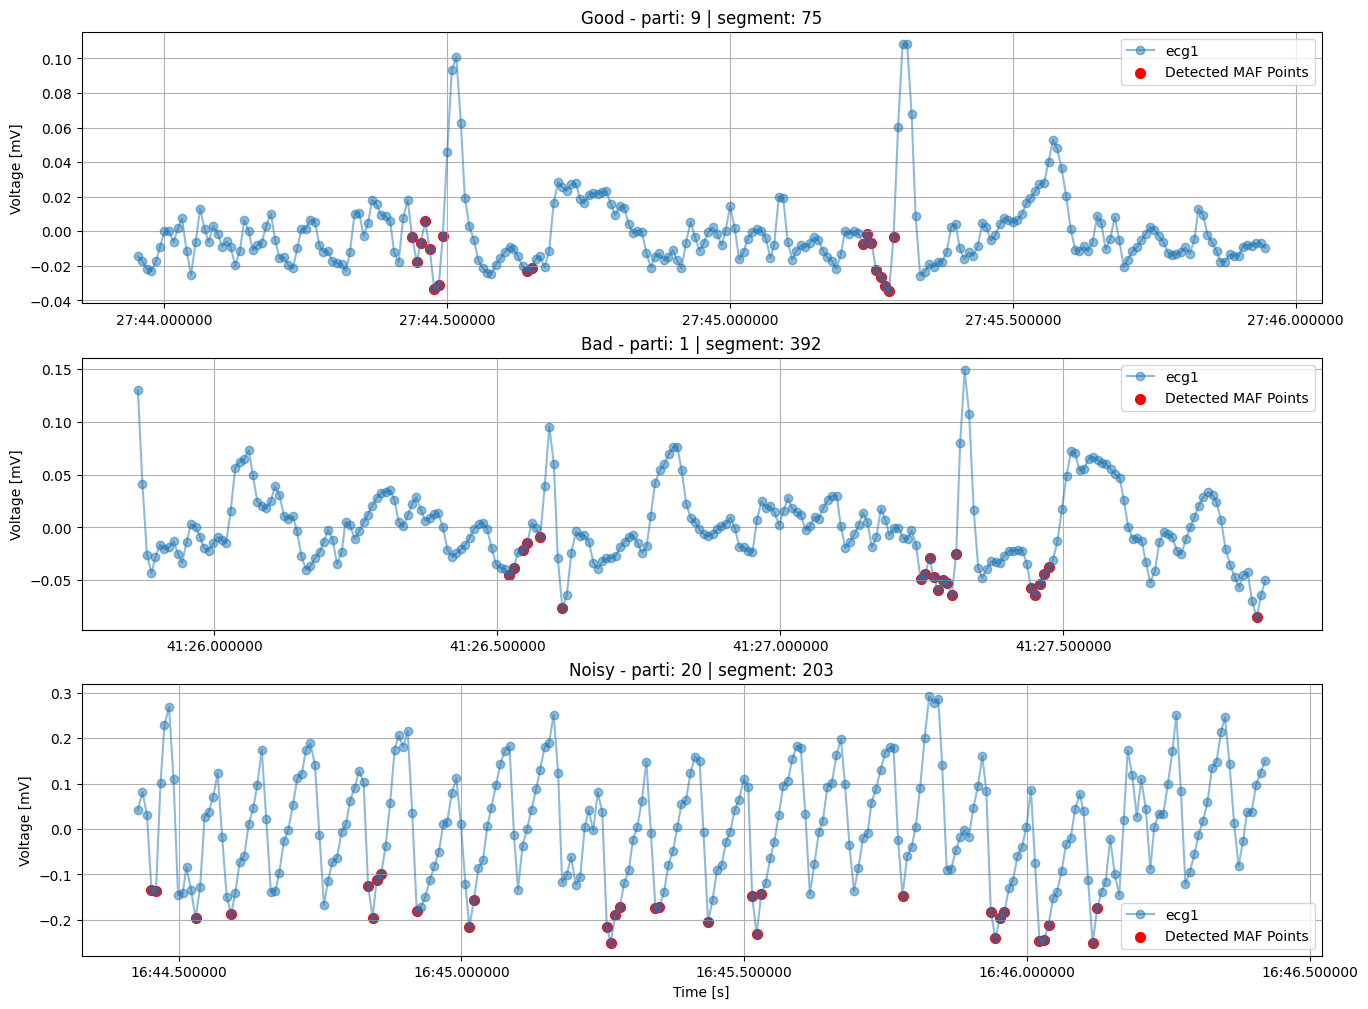

In [12]:
signals = get_random_signals(("good", "no_ma"), ("bad", "no_ma"), ("noisy", "no_ma"))
fig = plot_triple_data(dfs = signals, signal="ecg1", title= [f"Good - {signals[0].attrs['signal']}" , f"Bad - {signals[1].attrs['signal']}", f"Noisy - {signals[2].attrs['signal']}"])

In [13]:
fig.savefig("good-bad-noisy.pgf")

### 2- Good Data Variations with & without MA:
- Observations:
    - For the signals with the motion artifacts, there might be false detections.

In [ ]:
signals = get_random_signals(("good", "no_ma"), ("good", "no_ma"), ("good", "ma"))
fig = plot_triple_data(dfs = signals, signal="ecg1", title= [f"Good No Ma- {signals[0].attrs['signal']}" , f"Good No Ma - {signals[1].attrs['signal']}", f"Good MA - {signals[2].attrs['signal']}"])

In [ ]:
fig.savefig("ma-noma.pgf")

### 2- Good & MA Data - Derivations:
- Observations:
    - For the signals with the motion artifacts, detection from 1st & 2nd order derivation is helpful.

In [ ]:
signals = get_random_signals(("good", "ma"), ("good", "no_ma"), ("good", "ma"))
signal_derivatives = [signals[0], signals[0].diff(), signals[0].diff().diff()]
fig = plot_triple_data(dfs = signal_derivatives, signal="ecg1", title= [f"Raw - {signals[0].attrs['signal']}" , f"1st Derivative", f"2nd derivative"])

In [ ]:
fig.savefig("derivatives.pgf")

#### 2.2- Bad & MA Data - Derivations:
- Observations:

In [ ]:
signals = get_random_signals(("bad", "ma"), ("good", "no_ma"), ("good", "ma"))
signal_derivatives = [signals[0], signals[0].diff(), signals[0].diff().diff()]
fig = plot_triple_data(dfs = signal_derivatives, signal="ecg1", title= [f"Raw - {signals[0].attrs['signal']}" , f"1st Derivative", f"2nd derivative"])

#### 2.3- Noisy & MA Data - Derivations:
- Observations:
    - Mostly it finds large amount of peaks, which is good for discrimination.

In [ ]:
signals = get_random_signals(("noisy", "ma"), ("good", "no_ma"), ("good", "ma"))
signal_derivatives = [signals[0], signals[0].diff(), signals[0].diff().diff()]
fig = plot_triple_data(dfs = signal_derivatives, signal="ecg1", title= [f"Raw - {signals[0].attrs['signal']}" , f"1st Derivative", f"2nd derivative"])

#### 2.4- Good - Bad - Noisy, without MA, 2nd Derivations:
- Observations:


In [ ]:
signals = get_random_signals(("good", "no_ma"), ("bad", "no_ma"), ("noisy", "no_ma"))
signal_derivatives = [signals[0].diff().diff(),signals[1].diff().diff(),signals[2].diff().diff()]
fig = plot_triple_data(dfs = signal_derivatives, signal="ecg1", title= [f"Good - {signals[0].attrs['signal']} 2nd derivative", f"Bad - {signals[1].attrs['signal']} 2nd derivative", f"Noisy - {signals[2].attrs['signal']} 2nd derivative"])

In [ ]:
fig.savefig("good-bad-noisy-no-ma-second-der.pgf")

#### 2.4- Good - Bad - Noisy, with MA, 2nd Derivations:
- Observations:


In [ ]:
signals = get_random_signals(("good", "ma"), ("bad", "ma"), ("noisy", "ma"))
signal_derivatives = [signals[0].diff().diff(),signals[1].diff().diff(),signals[2].diff().diff()]
fig = plot_triple_data(dfs = signal_derivatives, signal="ecg1", title= [f"Good - {signals[0].attrs['signal']} 2nd derivative", f"Bad - {signals[1].attrs['signal']} 2nd derivative", f"Noisy - {signals[2].attrs['signal']} 2nd derivative"])

In [ ]:
signal_derivatives = [signals[0].diff().diff(),signals[1].diff().diff(),signals[2].diff().diff()]
fig = plot_triple_data(dfs = signal_derivatives, signal="ecg1", title= [f"Good - {signals[0].attrs['signal']} - 2nd Derivative Signal", f"Bad - {signals[1].attrs['signal']} - 2nd Derivative Signal", f"Noisy - {signals[2].attrs['signal']} - 2nd Derivative Signal"])

In [ ]:
fig.savefig("good-bad-noisy--ma-second-der.pgf")

In [ ]:
signal_derivatives = [signals[0],signals[1],signals[2]]
fig = plot_triple_data(dfs = signal_derivatives, signal="ecg1", title= [f"Good - {signals[0].attrs['signal']} - Unfiltered Signal", f"Bad - {signals[1].attrs['signal']}- Unfiltered Signal", f"Noisy - {signals[2].attrs['signal']} - Unfiltered Signal"])

In [ ]:
fig.savefig("good-bad-noisy--ma-unfiltered.pgf")